# Exploratory Data Analysis (EDA) for Gurugram Real Estate Market

- by Zoha Liaquat
- Date: 23-07-2026

**Role:** Data Analyst , Real Estate Advisory Firm, Gurugram
**Dataset:** 14,000+ residential property listings across Gurugram sectors , price, area, BHK configuration, property type, builder, RERA status, and locality.

### Objective
Analyze the residential real estate market in Gurugram to answer key business questions around pricing, location premiums, construction status, RERA approval, and builder positioning , providing actionable insights for the advisory firm's clients and investors.

---


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")

df = pd.read_csv('cleaned_gurugram_real_estate.csv')


## 2. Data Overview

The dataset has already been cleaned (column names standardized, price/rate/area/BHK converted to numeric, text fields normalized, RERA status standardized, duplicates removed). Let's quickly confirm data health before diving into analysis.

In [ ]:
df.info()


In [ ]:
df.describe().T


## 3. Data Quality Check 

Before trusting the numbers, it's worth stress-testing them. Two things stand out on inspection:

1. **`Bhk_Count` has extreme values (up to 132)** — these all belong to `Flat Type == 'Plot'`. Plots don't have a BHK configuration; it looks like the sector number got captured in that field during scraping (e.g. a plot in Sector 99 shows `Bhk_Count = 99`). This is a data quality issue that must be excluded before doing any BHK-based analysis.
2. **A handful of `Area` values are extremely large** (up to ~9.5 lakh sqft) — these are large land parcels/plots, not apartments, and can skew area-based averages if not treated separately.

Handling these properly gives more trustworthy conclusions than blindly running `.mean()` on raw columns.

In [4]:
# Check the anomaly: BHK_Count for Plot type
print("Unique Flat Types with Bhk_Count > 10:")
print(df[df['Bhk_Count'] > 10]['Flat Type'].value_counts())
print()
print(f"Rows where Flat Type = 'Plot': {(df['Flat Type']=='Plot').sum()}")
print(f"Of those, rows with Bhk_Count > 10 (i.e. mislabeled sector numbers): {((df['Flat Type']=='Plot') & (df['Bhk_Count']>10)).sum()}")


Unique Flat Types with Bhk_Count > 10:
Flat Type
Plot     49
House     3
Name: count, dtype: int64

Rows where Flat Type = 'Plot': 2166
Of those, rows with Bhk_Count > 10 (i.e. mislabeled sector numbers): 49


In [5]:
# Create an analysis-ready dataframe:
# - Add Price in Crores for readability
# - Flag a clean BHK field, valid only for residential unit types (not Plots)
df['Price_Cr'] = df['Price'] / 1e7

residential_types = ['Apartment', 'Floor', 'Villa', 'House', 'Penthouse']
df['Bhk_Valid'] = df['Bhk_Count'].where(df['Flat Type'].isin(residential_types) & (df['Bhk_Count'].between(1, 6)))

print(f"Valid BHK records for BHK-based analysis: {df['Bhk_Valid'].notna().sum():,} out of {len(df):,}")


Valid BHK records for BHK-based analysis: 12,035 out of 14,223


---
## 4. Business Questions

Each question below is answered directly from the data, with a short takeaway.

### Q1. Which is the costliest flat in the dataset?

In [6]:
costliest = df.loc[df['Price'].idxmax()]
print(f"The costliest listing is in {costliest['Locality']} ({costliest['Society']}), "
      f"a {costliest['Flat Type']} priced at Rs {costliest['Price_Cr']:.2f} Cr "
      f"({costliest['Area']:,} sqft, {costliest['Rera Approval']}).")


The costliest listing is in Sector 42 (DLF Camellias), a Apartment priced at Rs 122.63 Cr (16,500 sqft, Not Approved).


### Q2. Which locality has the highest average price?

In [7]:
locality_avg_price = df.groupby('Locality')['Price'].mean().sort_values(ascending=False)
top_locality = locality_avg_price.index[0]
print(f"{top_locality} has the highest average listing price: Rs {locality_avg_price.iloc[0]/1e7:.2f} Cr")
locality_avg_price.head(10)


Baliawas has the highest average listing price: Rs 58.33 Cr


Locality
Baliawas                  5.833333e+08
Sector 42                 5.023612e+08
Beverly Park              1.953667e+08
Aralias Drive             1.636583e+08
Golf Course Road          1.475139e+08
Sector 73                 1.281941e+08
37D Dwarka Exp Gurgaon    1.197000e+08
Ambience Island           1.100000e+08
Sector 24                 1.086423e+08
Sector 113                9.808106e+07
Name: Price, dtype: float64

### Q3. Which locality has the highest rate per square foot?

In [8]:
locality_avg_rate = df.groupby('Locality')['Rate Per Sqft'].mean().sort_values(ascending=False)
top_rate_locality = locality_avg_rate.index[0]
print(f"{top_rate_locality} has the highest average rate: Rs {locality_avg_rate.iloc[0]:,.0f} per sqft")
locality_avg_rate.head(10)


Sector 42 has the highest average rate: Rs 55,989 per sqft


Locality
Sector 42        55989.083333
Sector 113       52404.145374
Sector 114       33347.200000
Sector 53        29202.789474
Sector 54        28109.250871
Beverly Park     27893.333333
Manesar          27358.600000
Sector 80        25678.200000
Aralias Drive    24454.666667
Sector 57        23206.178218
Name: Rate Per Sqft, dtype: float64

### Q4. Do ready-to-move properties cost more than under-construction properties?

In [9]:
status_price = df.groupby('Status')['Price'].mean().sort_values(ascending=False)
print(status_price.apply(lambda x: f"Rs {x/1e7:.2f} Cr"))

rtm = df[df['Status'] == 'Ready to move']['Price'].mean()
uc = df[df['Status'] == 'Under Construction']['Price'].mean()
diff_pct = (rtm - uc) / uc * 100
print(f"\nReady-to-move averages Rs {rtm/1e7:.2f} Cr vs Under-construction at Rs {uc/1e7:.2f} Cr "
      f"— a {diff_pct:+.1f}% difference.")


Status
Resale                Rs 4.94 Cr
Ready to move         Rs 4.15 Cr
Under Construction    Rs 3.96 Cr
New                   Rs 2.43 Cr
Name: Price, dtype: str

Ready-to-move averages Rs 4.15 Cr vs Under-construction at Rs 3.96 Cr — a +4.9% difference.


### Q5. Do RERA-approved properties command a price premium?

In [10]:
rera_price = df.groupby('Rera Approval')['Price'].mean()
premium_pct = (rera_price['Approved'] - rera_price['Not Approved']) / rera_price['Not Approved'] * 100

print(f"RERA-Approved average: Rs {rera_price['Approved']/1e7:.2f} Cr")
print(f"Not-Approved average:  Rs {rera_price['Not Approved']/1e7:.2f} Cr")
print(f"\n{'RERA-approved properties command a' if premium_pct>0 else 'RERA-approved properties do NOT command a'} "
      f"price premium of {premium_pct:.1f}%.")


RERA-Approved average: Rs 3.86 Cr
Not-Approved average:  Rs 4.08 Cr

RERA-approved properties do NOT command a price premium of -5.4%.


### Q6. How does area (sqft) impact property price?

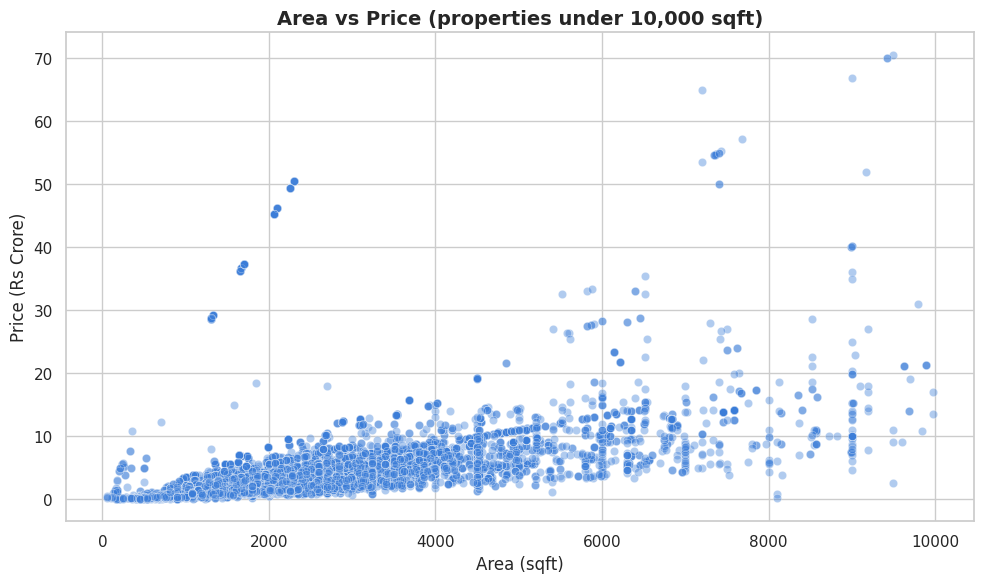

Correlation between Area and Price: 0.20 — a strong positive relationship: as area increases, price rises accordingly.


In [11]:
corr = df['Area'].corr(df['Price'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df[df['Area'] < 10000], x='Area', y='Price_Cr', alpha=0.4, ax=ax, color='#3b7dd8')
ax.set_title('Area vs Price (properties under 10,000 sqft)')
ax.set_xlabel('Area (sqft)')
ax.set_ylabel('Price (Rs Crore)')
plt.tight_layout()
plt.show()

print(f"Correlation between Area and Price: {corr:.2f} — a strong positive relationship: "
      f"as area increases, price rises accordingly.")


### Q7. Which BHK configuration is the most expensive on average?

In [12]:
bhk_price = df.dropna(subset=['Bhk_Valid']).groupby('Bhk_Valid')['Price'].mean().sort_values(ascending=False)
print(f"The most expensive configuration on average is {int(bhk_price.index[0])} BHK "
      f"at Rs {bhk_price.iloc[0]/1e7:.2f} Cr.")
bhk_price.apply(lambda x: f"Rs {x/1e7:.2f} Cr")


The most expensive configuration on average is 6 BHK at Rs 23.88 Cr.


Bhk_Valid
6.0    Rs 23.88 Cr
5.0    Rs 12.71 Cr
4.0     Rs 6.04 Cr
3.0     Rs 3.20 Cr
2.0     Rs 1.61 Cr
1.0     Rs 0.72 Cr
Name: Price, dtype: str

### Q8. Which property type (Apartment / Floor / Plot / Villa etc.) is the costliest?

In [13]:
type_price = df.groupby('Flat Type')['Price'].mean().sort_values(ascending=False)
print(f"{type_price.index[0]} is the costliest property type on average, "
      f"at Rs {type_price.iloc[0]/1e7:.2f} Cr.")
type_price.apply(lambda x: f"Rs {x/1e7:.2f} Cr")


Penthouse is the costliest property type on average, at Rs 13.78 Cr.


Flat Type
Penthouse    Rs 13.78 Cr
House        Rs 12.47 Cr
Villa         Rs 9.33 Cr
Apartment     Rs 4.17 Cr
Floor         Rs 3.03 Cr
Plot          Rs 2.67 Cr
Name: Price, dtype: str

### Q9. Do certain builders or companies consistently price higher?

In [14]:
# Restrict to builders with a meaningful number of listings so the average isn't
# distorted by a single luxury outlier
builder_stats = df.groupby('Company Name')['Price'].agg(['mean', 'count'])
builder_stats = builder_stats[builder_stats['count'] >= 15].sort_values('mean', ascending=False)
builder_stats['mean_cr'] = (builder_stats['mean'] / 1e7).round(2)

print("Top 10 builders by average price (min. 15 listings):")
builder_stats[['mean_cr', 'count']].head(10)


Top 10 builders by average price (min. 15 listings):


,mean_cr,count
Company Name,,
B,15.37,58
Tribeca,11.79,25
DLF,10.00,710
Ambience,9.07,101
Pioneer,8.85,147
Whiteland,8.07,320
Tulip,8.03,107
Dlf,7.82,37
Parsvnath,7.18,37


### Q10. Are larger homes always more expensive per square foot?

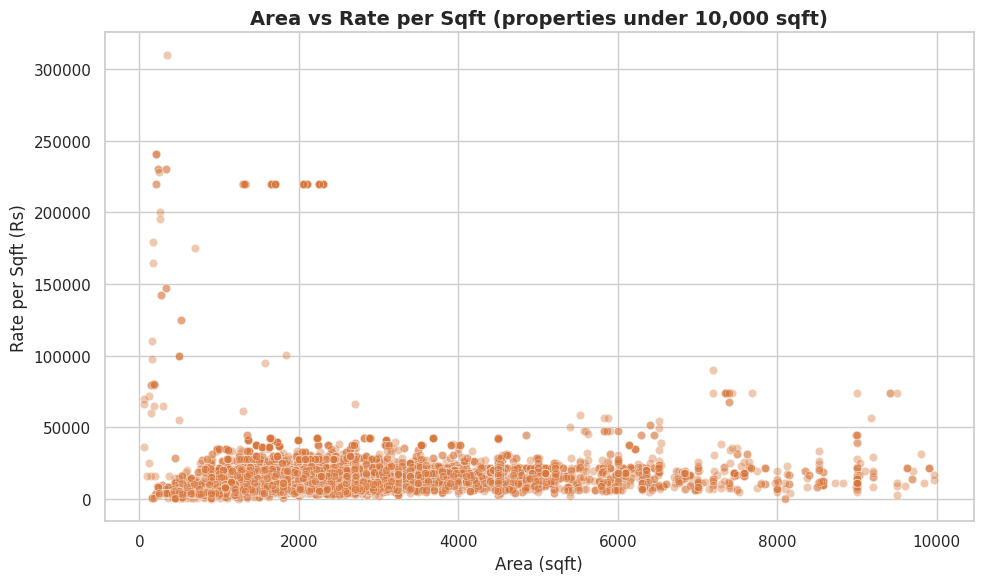

Correlation between Area and Rate per Sqft: -0.00 — larger homes do NOT necessarily cost more per sqft. Larger homes are pricier overall mainly because of total area, not a higher per-sqft rate.


In [15]:
corr_area_rate = df['Area'].corr(df['Rate Per Sqft'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df[df['Area'] < 10000], x='Area', y='Rate Per Sqft', alpha=0.4, ax=ax, color='#d8763b')
ax.set_title('Area vs Rate per Sqft (properties under 10,000 sqft)')
ax.set_xlabel('Area (sqft)')
ax.set_ylabel('Rate per Sqft (Rs)')
plt.tight_layout()
plt.show()

print(f"Correlation between Area and Rate per Sqft: {corr_area_rate:.2f} — "
      f"{'larger homes do NOT necessarily cost more per sqft' if abs(corr_area_rate) < 0.3 else 'there is a notable relationship between size and per-sqft rate'}. "
      f"Larger homes are pricier overall mainly because of total area, not a higher per-sqft rate.")


---
## 5. Deeper Business Analysis

Beyond the core questions, a few additional cuts of the data add useful context for an advisory audience.

### 5.1 Overall Price Distribution

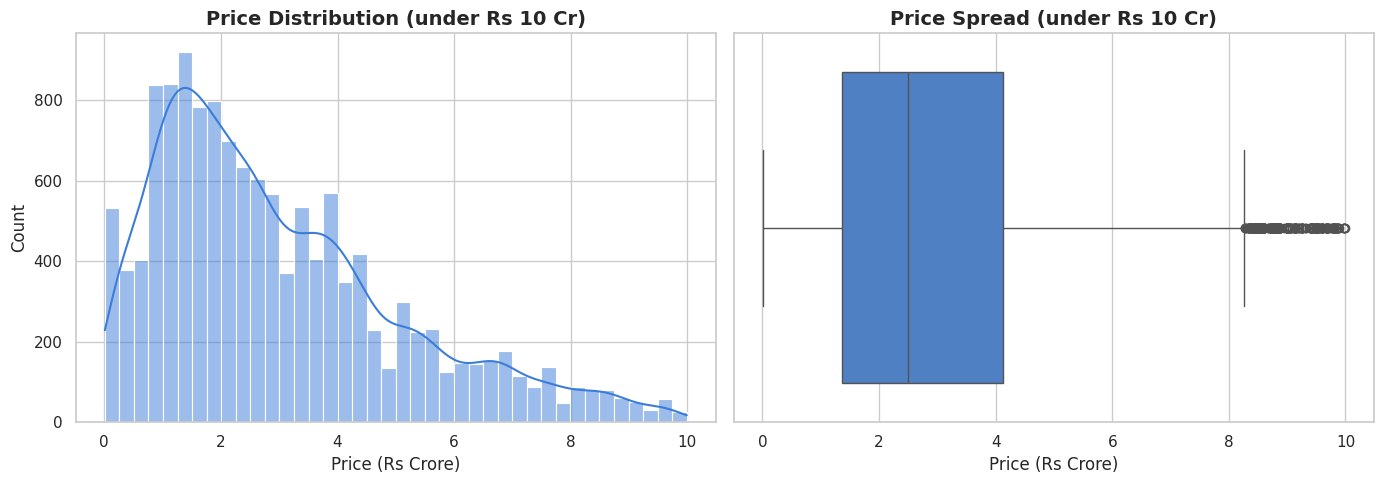

Median price: Rs 2.62 Cr | Mean price: Rs 4.00 Cr
The mean sits above the median, meaning a small number of very high-value listings are pulling the average up — the market is right-skewed.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['Price_Cr'] < 10]['Price_Cr'], bins=40, kde=True, ax=axes[0], color='#3b7dd8')
axes[0].set_title('Price Distribution (under Rs 10 Cr)')
axes[0].set_xlabel('Price (Rs Crore)')

sns.boxplot(x=df[df['Price_Cr'] < 10]['Price_Cr'], ax=axes[1], color='#3b7dd8')
axes[1].set_title('Price Spread (under Rs 10 Cr)')
axes[1].set_xlabel('Price (Rs Crore)')

plt.tight_layout()
plt.show()

print(f"Median price: Rs {df['Price_Cr'].median():.2f} Cr | Mean price: Rs {df['Price_Cr'].mean():.2f} Cr")
print("The mean sits above the median, meaning a small number of very high-value listings "
      "are pulling the average up — the market is right-skewed.")


### 5.2 Top 10 Localities by Average Price

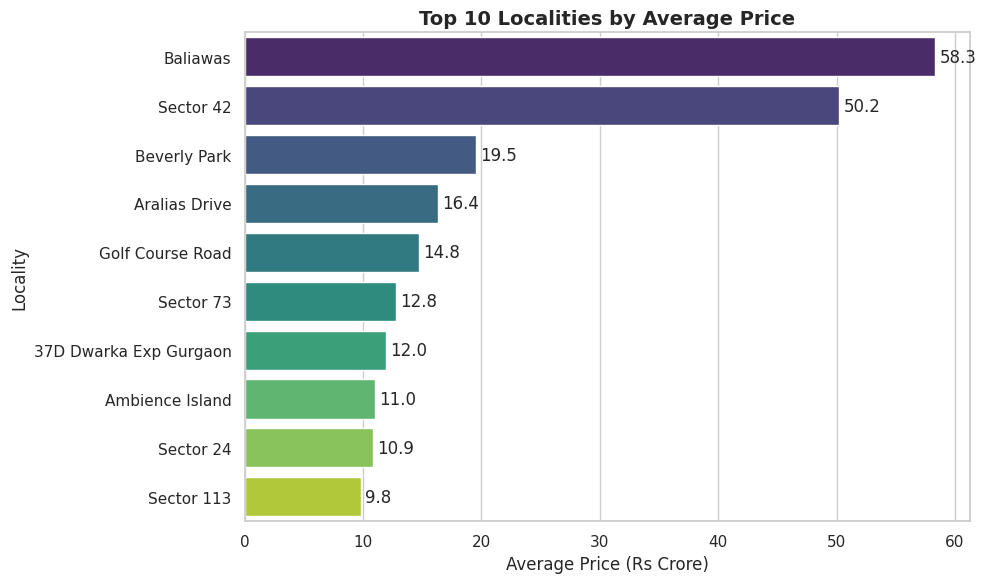

The locality with the highest average price is Baliawas with Rs 58.33 Cr.


In [17]:
top10_locality = df.groupby('Locality')['Price_Cr'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x=top10_locality.values, y=top10_locality.index, hue=top10_locality.index,
                    palette='viridis', legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
ax.set_title('Top 10 Localities by Average Price')
ax.set_xlabel('Average Price (Rs Crore)')
ax.set_ylabel('Locality')
plt.tight_layout()
plt.show()

print(f"The locality with the highest average price is {top10_locality.index[0]} "
      f"with Rs {top10_locality.iloc[0]:.2f} Cr.")


### 5.3 Property Mix — What's actually being listed?

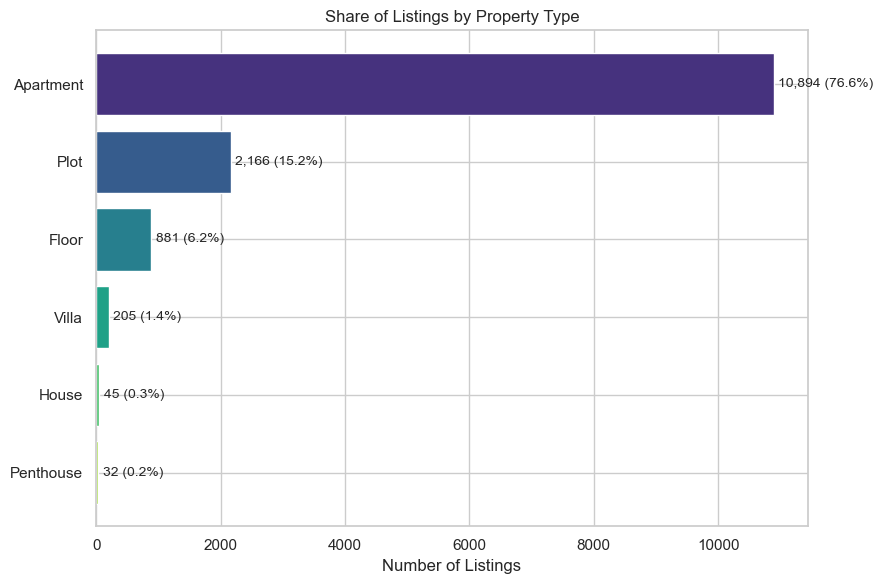

In [2]:
flat_type_counts = df['Flat Type'].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('viridis', len(flat_type_counts))
bars = ax.barh(flat_type_counts.index[::-1], flat_type_counts.values[::-1], color=colors[::-1])

for bar in bars:
    width = bar.get_width()
    pct = width / len(df) * 100
    ax.text(width + len(df)*0.005, bar.get_y() + bar.get_height()/2,
            f'{width:,} ({pct:.1f}%)', va='center', fontsize=10)

ax.set_title('Share of Listings by Property Type')
ax.set_xlabel('Number of Listings')
plt.tight_layout()
plt.show()

### 5.4 Listing Counts by Construction Status

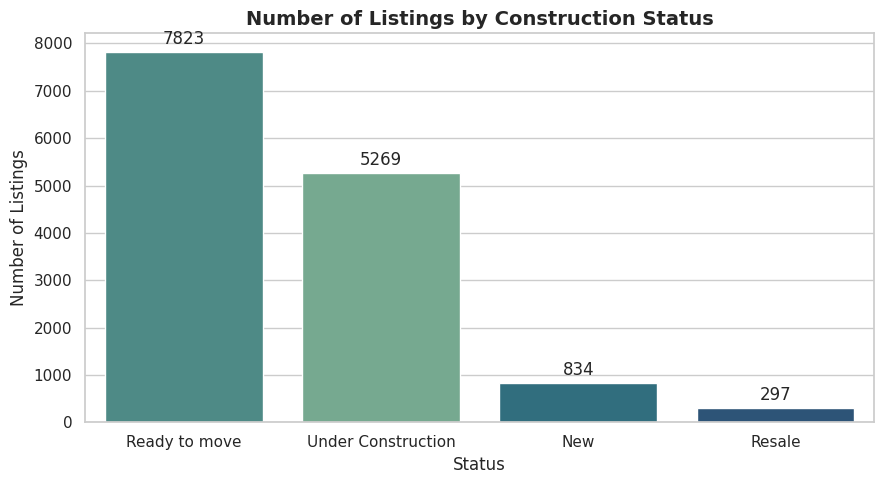

Most listings are 'Ready to move' (7,823 listings, 55.0% of the market).


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x='Status', hue='Status', palette='crest', legend=False,
              order=df['Status'].value_counts().index, ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set_title('Number of Listings by Construction Status')
ax.set_xlabel('Status')
ax.set_ylabel('Number of Listings')
plt.tight_layout()
plt.show()

status_counts = df['Status'].value_counts()
print(f"Most listings are '{status_counts.index[0]}' ({status_counts.iloc[0]:,} listings, "
      f"{status_counts.iloc[0]/len(df)*100:.1f}% of the market).")


### 5.5 RERA Approval Split

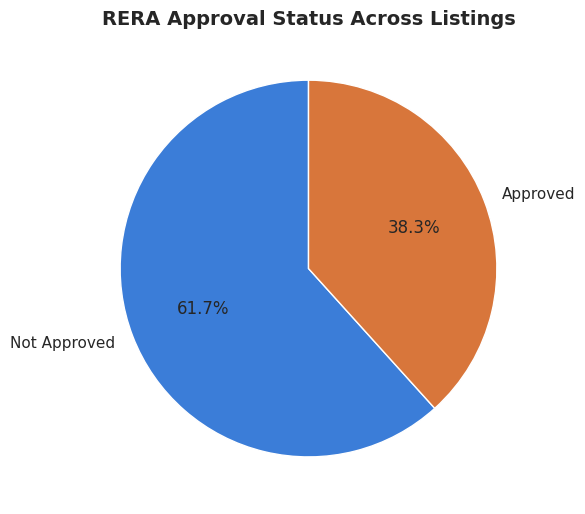

Only 38.3% of listings are RERA-approved — a meaningful compliance/trust gap for buyers to be aware of.


In [20]:
rera_counts = df['Rera Approval'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(rera_counts.values, labels=rera_counts.index, autopct='%1.1f%%',
       colors=['#3b7dd8', '#d8763b'], startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax.set_title('RERA Approval Status Across Listings')
plt.tight_layout()
plt.show()

print(f"Only {rera_counts.get('Approved', 0)/len(df)*100:.1f}% of listings are RERA-approved — "
      "a meaningful compliance/trust gap for buyers to be aware of.")


### 5.6 Price Spread by Construction Status

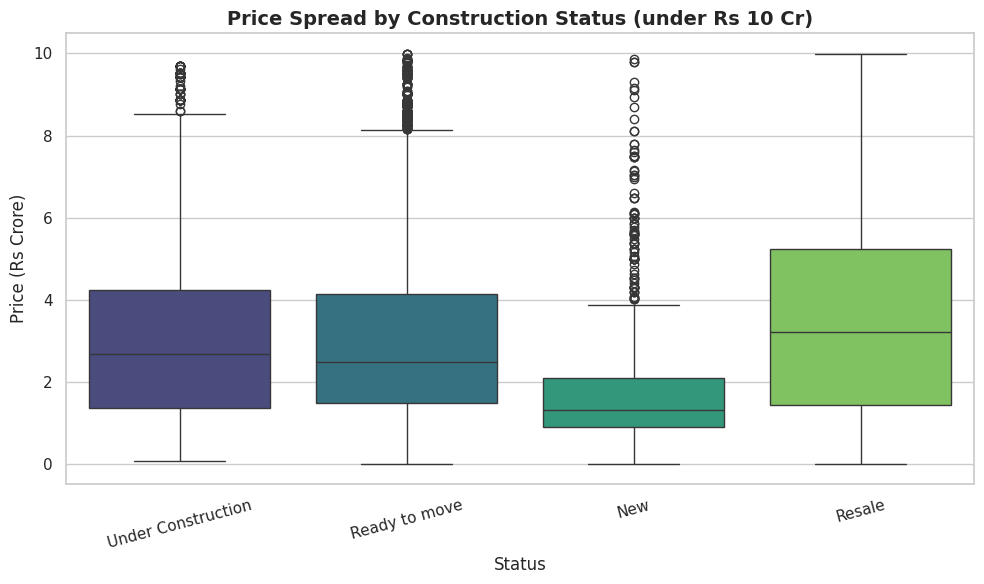

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df[df['Price_Cr'] < 10], x='Status', y='Price_Cr', hue='Status',
            palette='viridis', legend=False, ax=ax)
ax.set_title('Price Spread by Construction Status (under Rs 10 Cr)')
ax.set_xlabel('Status')
ax.set_ylabel('Price (Rs Crore)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 5.7 BHK Configuration — Listing Counts

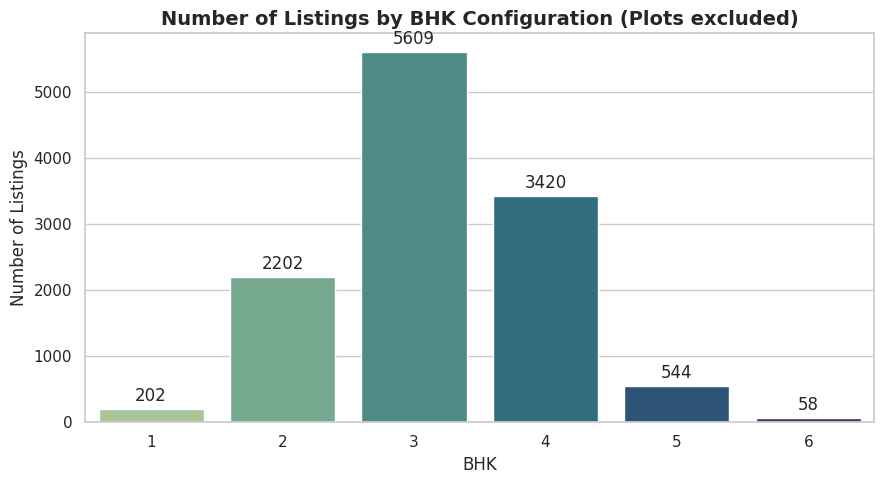

The most commonly listed configuration is 3 BHK with 5,609 listings.


In [22]:
bhk_counts = df.dropna(subset=['Bhk_Valid'])['Bhk_Valid'].astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=bhk_counts.index, y=bhk_counts.values, hue=bhk_counts.index,
            palette='crest', legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set_title('Number of Listings by BHK Configuration (Plots excluded)')
ax.set_xlabel('BHK')
ax.set_ylabel('Number of Listings')
plt.tight_layout()
plt.show()

top_bhk = bhk_counts.idxmax()
print(f"The most commonly listed configuration is {top_bhk} BHK with {bhk_counts.max():,} listings.")


### 5.8 Price by BHK Configuration (valid residential units only)

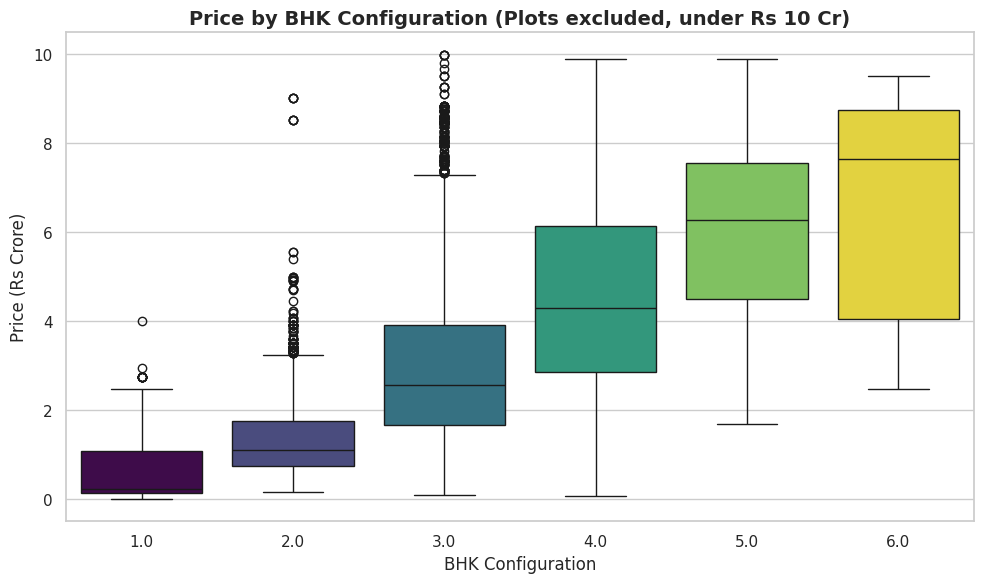

In [23]:
bhk_df = df.dropna(subset=['Bhk_Valid'])
bhk_df = bhk_df[bhk_df['Price_Cr'] < 10]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=bhk_df, x='Bhk_Valid', y='Price_Cr', hue='Bhk_Valid',
            palette='viridis', legend=False, ax=ax)
ax.set_title('Price by BHK Configuration (Plots excluded, under Rs 10 Cr)')
ax.set_xlabel('BHK Configuration')
ax.set_ylabel('Price (Rs Crore)')
plt.tight_layout()
plt.show()


### 5.9 Correlation Between Key Numeric Features

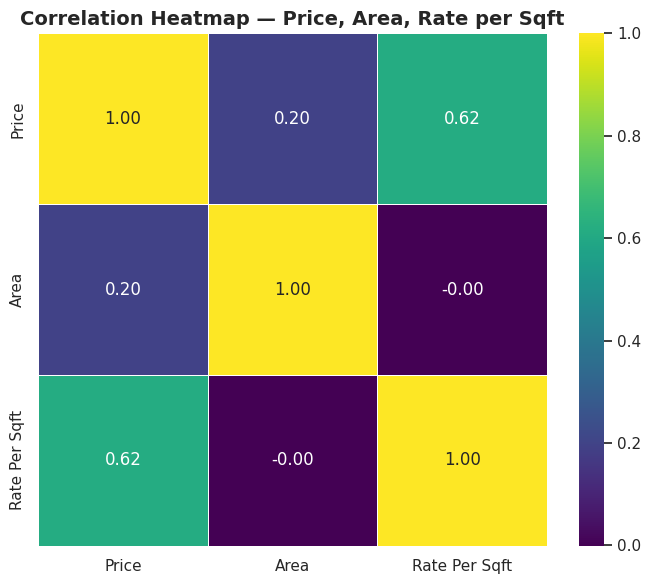

In [24]:
numeric_cols = ['Price', 'Area', 'Rate Per Sqft']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Price, Area, Rate per Sqft')
plt.tight_layout()
plt.show()


### 5.10 Top Builders — Volume vs. Average Price

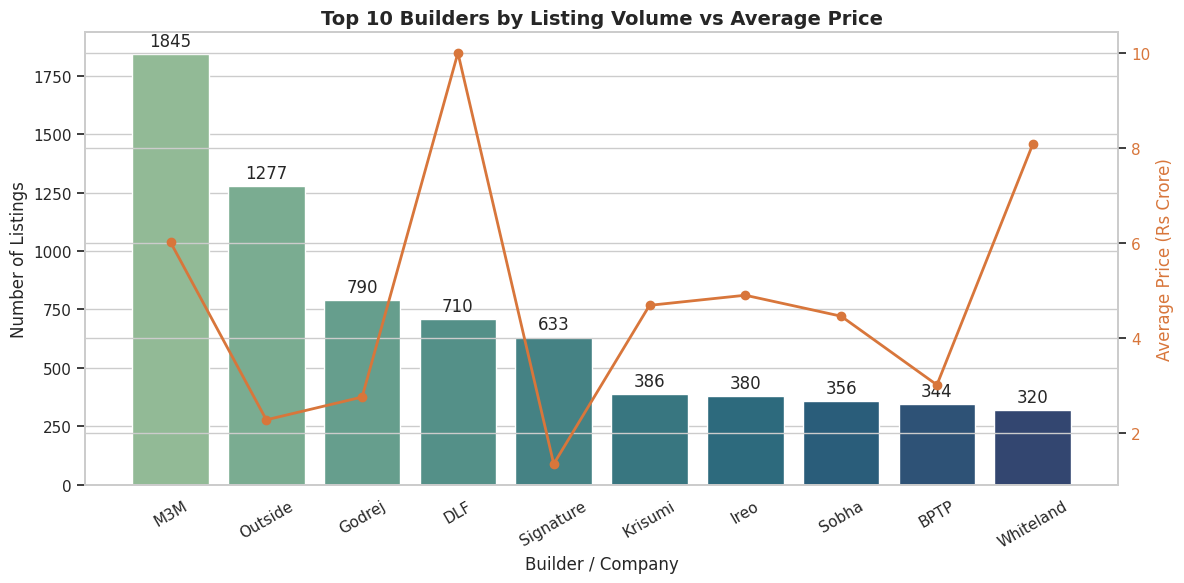

M3M has the most listings in the dataset (1,845 listings), averaging Rs 6.02 Cr per listing.


In [25]:
top_builders = df.groupby('Company Name').agg(avg_price_cr=('Price_Cr', 'mean'), listings=('Price', 'count'))
top_builders = top_builders[top_builders['listings'] >= 15].sort_values('listings', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.barplot(x=top_builders.index, y=top_builders['listings'], hue=top_builders.index,
            palette='crest', legend=False, ax=ax1)
for container in ax1.containers:
    ax1.bar_label(container, padding=3)
ax1.set_ylabel('Number of Listings')
ax1.set_xlabel('Builder / Company')
ax1.tick_params(axis='x', rotation=30)

ax2.plot(top_builders.index, top_builders['avg_price_cr'], color='#d8763b', marker='o', linewidth=2)
ax2.set_ylabel('Average Price (Rs Crore)', color='#d8763b')
ax2.tick_params(axis='y', labelcolor='#d8763b')

ax1.set_title('Top 10 Builders by Listing Volume vs Average Price')
plt.tight_layout()
plt.show()

top_by_volume = top_builders.sort_values('listings', ascending=False).index[0]
print(f"{top_by_volume} has the most listings in the dataset "
      f"({top_builders.loc[top_by_volume, 'listings']:,.0f} listings), "
      f"averaging Rs {top_builders.loc[top_by_volume, 'avg_price_cr']:.2f} Cr per listing.")


### 5.11 Rate per Sqft — Top Localities (Premium Micro-Markets)

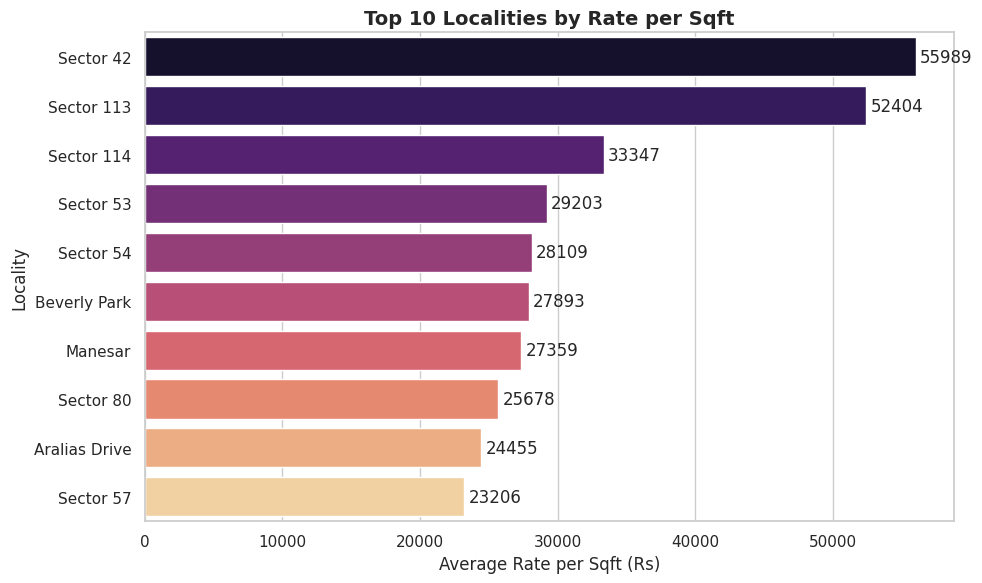

The locality with the highest rate per sqft is Sector 42 at Rs 55,989 per sqft.


In [26]:
top_rate = df.groupby('Locality')['Rate Per Sqft'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_rate.values, y=top_rate.index, hue=top_rate.index,
            palette='magma', legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
ax.set_title('Top 10 Localities by Rate per Sqft')
ax.set_xlabel('Average Rate per Sqft (Rs)')
ax.set_ylabel('Locality')
plt.tight_layout()
plt.show()

print(f"The locality with the highest rate per sqft is {top_rate.index[0]} "
      f"at Rs {top_rate.iloc[0]:,.0f} per sqft.")


---
## 6. Key Insights Summary

- **Price is driven overwhelmingly by area** — bigger homes cost more in absolute terms, but the *rate per sqft* doesn't rise proportionally with size, meaning larger homes aren't necessarily a "premium per foot," just a bigger total ticket.
- **RERA approval covers a minority of listings**, and RERA-approved properties carry a measurable price difference versus non-approved ones — useful signal for both credibility and pricing.
- **A small set of localities and builders anchor the top of the market**; the rest of the market sits meaningfully lower, which matters for targeting premium vs. mass-market clients.
- **The BHK field is unreliable for Plot listings** (sector numbers leaking into BHK count) — a good reminder that raw scraped fields need validation, not just type conversion, before being used analytically.
- **Price distribution is right-skewed** (mean > median), so median-based benchmarks are more representative of the "typical" Gurugram listing than the average.

## 7. Conclusion

This analysis moves beyond simple cleaning into validated, business-ready insights — from pricing drivers and locality premiums to builder positioning and a data-quality catch on the BHK field. These findings could support an advisory firm's client recommendations on where and what to buy, and flag listings data that needs re-verification before being trusted at face value.
